# Hubbard Exact Diagonalization

**Model.** This notebook compares truncated Bose-Hubbard and spinful Fermi-Hubbard chains. The Bose-Hubbard basis is `|0>, ..., |max_occupancy>` per site. The Fermi-Hubbard basis uses orbital order `site0_up, site0_down, site1_up, site1_down, ...`.

**Typical uses.** Small interacting-lattice benchmarks, occupation-basis exact diagonalization, sparse low-energy calculations, and reference spectra for quantum simulation algorithms.

**Parameters.** `n_sites` sets chain length; `hopping` is `t`; `interaction` is `U`; `chemical_potential` is `mu`; `max_occupancy` truncates bosonic local Hilbert space; `periodic` controls boundary conditions.

**Useful plots.** Low-energy spectra, density-of-states histograms, and comparisons between dense and sparse eigensolvers.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from quantum_lattice_models.models import (
    bose_hubbard_chain,
    bose_hubbard_chain_sparse,
    fermi_hubbard_chain,
    fermi_hubbard_chain_sparse,
)
from quantum_lattice_models.plotting import plot_lattice_spectrum
from quantum_lattice_models.spectra import ground_state, lowest_eigenvalues

In [ ]:
bose_dense = bose_hubbard_chain(
    n_sites=3, hopping=0.6, interaction=1.5, chemical_potential=0.2, max_occupancy=2
)
bose_sparse = bose_hubbard_chain_sparse(
    n_sites=3, hopping=0.6, interaction=1.5, chemical_potential=0.2, max_occupancy=2
)
fermi_dense = fermi_hubbard_chain(n_sites=3, hopping=0.5, interaction=3.0)
fermi_sparse = fermi_hubbard_chain_sparse(n_sites=3, hopping=0.5, interaction=3.0)

print("model          | dense shape | sparse shape | nonzeros")
print("---            | ---         | ---          | ---")
print(
    f"Bose-Hubbard   | {str(bose_dense.shape):<11s} | {str(bose_sparse.shape):<12s} | {bose_sparse.nnz}"
)
print(
    f"Fermi-Hubbard  | {str(fermi_dense.shape):<11s} | {str(fermi_sparse.shape):<12s} | {fermi_sparse.nnz}"
)

model          | dense shape | sparse shape | nonzeros
---            | ---         | ---          | ---
Bose-Hubbard   | (27, 27)    | (27, 27)     | 74
Fermi-Hubbard  | (64, 64)    | (64, 64)     | 165


In [3]:
bose_lowest = lowest_eigenvalues(bose_sparse, k=4)
energy, state = ground_state(fermi_sparse)
print("Low-energy summary")
print("  Bose lowest eigenvalues:", np.array2string(bose_lowest, precision=6, separator=", "))
print(f"  Fermi ground energy:     {energy: .6f}")
print(f"  Ground-state norm:       {np.linalg.norm(state): .6f}")

Low-energy summary
  Bose lowest eigenvalues: [-1.902584, -1.714909, -1.33033 , -1.048528]
  Fermi ground energy:     -0.923637
  Ground-state norm:        1.000000


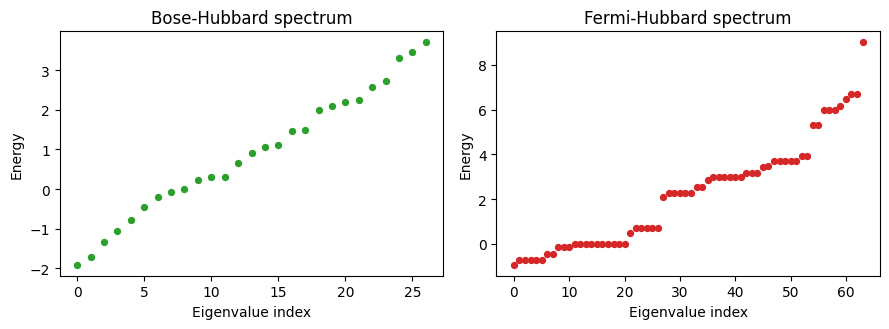

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
plot_lattice_spectrum(bose_dense, ax=axes[0], s=18, color="tab:green")
axes[0].set_title("Bose-Hubbard spectrum")
plot_lattice_spectrum(fermi_dense, ax=axes[1], s=18, color="tab:red")
axes[1].set_title("Fermi-Hubbard spectrum")
fig.tight_layout()